In [2]:
import pandas as pd
from google.colab import drive
from sklearn.preprocessing import StandardScaler, LabelEncoder

drive.mount('/content/drive')
file_path = ('/content/drive/MyDrive/MLproject/dating_app_behavior_dataset.csv')
df = pd.read_csv(file_path)
print(f"Dataset shape: {df.shape}")

Mounted at /content/drive
Dataset shape: (50000, 19)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
df.head()

,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [5]:
df.columns = [col.upper().replace("-", "").replace("_", "").strip() for col in df.columns]
column_mapping = {
    'GENDER': 'USER_GENDER',
    'LOCATION TYPE': 'LOCATION_CATEGORY',
    'INCOME BRACKET': 'INCOME_LEVEL',
    'APP USAGE TIME (MIN/DAY)': 'DAILY_USAGE_MINS',
    'LIKES RECEIVED': 'TOTAL_LIKES',
    'MATCH OUTCOME': 'TARGET_LABEL'
}

df.rename(columns=column_mapping, inplace=True)

print(df.columns)

Index(['USER_GENDER', 'SEXUALORIENTATION', 'LOCATIONTYPE', 'INCOMEBRACKET',
       'EDUCATIONLEVEL', 'INTERESTTAGS', 'APPUSAGETIMEMIN',
       'APPUSAGETIMELABEL', 'SWIPERIGHTRATIO', 'SWIPERIGHTLABEL',
       'LIKESRECEIVED', 'MUTUALMATCHES', 'PROFILEPICSCOUNT', 'BIOLENGTH',
       'MESSAGESENTCOUNT', 'EMOJIUSAGERATE', 'LASTACTIVEHOUR',
       'SWIPETIMEOFDAY', 'MATCHOUTCOME'],
      dtype='object')


In [6]:
df.head()

,USER_GENDER,SEXUALORIENTATION,LOCATIONTYPE,INCOMEBRACKET,EDUCATIONLEVEL,INTERESTTAGS,APPUSAGETIMEMIN,APPUSAGETIMELABEL,SWIPERIGHTRATIO,SWIPERIGHTLABEL,LIKESRECEIVED,MUTUALMATCHES,PROFILEPICSCOUNT,BIOLENGTH,MESSAGESENTCOUNT,EMOJIUSAGERATE,LASTACTIVEHOUR,SWIPETIMEOFDAY,MATCHOUTCOME
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,173,23,4,44,75,0.36,13,Early Morning,Mutual Match
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,107,7,3,301,35,0.42,0,Morning,Chat Ignored
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,91,27,2,309,33,0.41,1,After Midnight,Date Happened
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,147,6,5,35,5,0.07,21,Morning,No Action
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,94,11,1,343,34,0.11,22,After Midnight,One-sided Like


In [7]:
print(df.isnull().sum())

df.fillna(df.median(numeric_only=True), inplace=True)
for col in df.select_dtypes(include=['object']).columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

df.drop_duplicates(inplace=True)

USER_GENDER          0
SEXUALORIENTATION    0
LOCATIONTYPE         0
INCOMEBRACKET        0
EDUCATIONLEVEL       0
INTERESTTAGS         0
APPUSAGETIMEMIN      0
APPUSAGETIMELABEL    0
SWIPERIGHTRATIO      0
SWIPERIGHTLABEL      0
LIKESRECEIVED        0
MUTUALMATCHES        0
PROFILEPICSCOUNT     0
BIOLENGTH            0
MESSAGESENTCOUNT     0
EMOJIUSAGERATE       0
LASTACTIVEHOUR       0
SWIPETIMEOFDAY       0
MATCHOUTCOME         0
dtype: int64


/tmp/ipykernel_1626/3015475735.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [8]:
scaler = StandardScaler()
le = LabelEncoder()

categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(exclude=['object']).columns

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Preprocessing complete. Data is cleaned and normalized.")

Preprocessing complete. Data is cleaned and normalized.


In [9]:
df.to_csv('cleaned_dating_data.csv', index=False)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set a visually appealing style for our plots
sns.set_theme(style="whitegrid", palette="muted")

# Display the first few rows to confirm we are working with the processed data
display(df.head())

,USER_GENDER,SEXUALORIENTATION,LOCATIONTYPE,INCOMEBRACKET,EDUCATIONLEVEL,INTERESTTAGS,APPUSAGETIMEMIN,APPUSAGETIMELABEL,SWIPERIGHTRATIO,SWIPERIGHTLABEL,LIKESRECEIVED,MUTUALMATCHES,PROFILEPICSCOUNT,BIOLENGTH,MESSAGESENTCOUNT,EMOJIUSAGERATE,LASTACTIVEHOUR,SWIPETIMEOFDAY,MATCHOUTCOME
0,4,3,5,0,1,11276,-1.125564,5,0.503097,2,1.266875,1.002657,0.506961,-1.423861,0.854646,0.461100,0.213600,2,6
1,2,1,4,4,6,17484,1.483942,2,0.300530,2,0.128870,-0.754518,0.006150,0.351007,-0.516734,0.836006,-1.664903,5,2
2,3,5,4,1,5,22775,-1.160051,5,-0.459093,2,-0.147010,1.441951,-0.494661,0.406255,-0.585303,0.773521,-1.520402,0,3
3,1,3,0,6,8,6284,0.403354,2,-0.914868,0,0.818570,-0.864341,1.007773,-1.486016,-1.545268,-1.350944,1.369602,5,7
4,2,1,5,3,1,5456,-0.769200,3,-0.914868,0,-0.095283,-0.315224,-0.995473,0.641063,-0.551018,-1.101006,1.514102,0,8


In [11]:
print("Dataset Shape:", df.shape)
print("\n--- Data Types and Missing Values ---")
print(df.info())

print("\n--- Summary Statistics (Numerical) ---")
display(df.describe())

# The following line is removed as all categorical columns have been label encoded into numerical types.
# display(df.describe(include=['object']))

Dataset Shape: (50000, 19)

--- Data Types and Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   USER_GENDER        50000 non-null  int64  
 1   SEXUALORIENTATION  50000 non-null  int64  
 2   LOCATIONTYPE       50000 non-null  int64  
 3   INCOMEBRACKET      50000 non-null  int64  
 4   EDUCATIONLEVEL     50000 non-null  int64  
 5   INTERESTTAGS       50000 non-null  int64  
 6   APPUSAGETIMEMIN    50000 non-null  float64
 7   APPUSAGETIMELABEL  50000 non-null  int64  
 8   SWIPERIGHTRATIO    50000 non-null  float64
 9   SWIPERIGHTLABEL    50000 non-null  int64  
 10  LIKESRECEIVED      50000 non-null  float64
 11  MUTUALMATCHES      50000 non-null  float64
 12  PROFILEPICSCOUNT   50000 non-null  float64
 13  BIOLENGTH          50000 non-null  float64
 14  MESSAGESENTCOUNT   50000 non-null  float64
 15  EMOJ

,USER_GENDER,SEXUALORIENTATION,LOCATIONTYPE,INCOMEBRACKET,EDUCATIONLEVEL,INTERESTTAGS,APPUSAGETIMEMIN,APPUSAGETIMELABEL,SWIPERIGHTRATIO,SWIPERIGHTLABEL,LIKESRECEIVED,MUTUALMATCHES,PROFILEPICSCOUNT,BIOLENGTH,MESSAGESENTCOUNT,EMOJIUSAGERATE,LASTACTIVEHOUR,SWIPETIMEOFDAY,MATCHOUTCOME
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,50000.000000
mean,2.500400,3.511560,2.489680,2.986120,3.997100,20143.610300,1.026734e-16,2.315380,1.334399e-16,1.633900,9.219292e-17,6.650680e-17,2.829736e-17,6.131984e-17,7.290168e-17,-3.339551e-16,-1.016076e-16,2.484380,4.491020
std,1.710023,2.294387,1.704075,2.003788,2.576498,11597.870205,1.000010e+00,1.590964,1.000010e+00,1.016037,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.711331,2.871363
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.723336e+00,0.000000,-2.535398e+00,0.000000,-1.716078e+00,-1.523282e+00,-1.496284e+00,-1.727729e+00,-1.716691e+00,-1.788333e+00,-1.664903e+00,0.000000,0.000000
25%,1.000000,2.000000,1.000000,1.000000,2.000000,10116.750000,-8.726601e-01,2.000000,-6.616597e-01,1.000000,-8.711954e-01,-8.643412e-01,-9.954728e-01,-8.644668e-01,-8.595787e-01,-7.885852e-01,-9.424015e-01,1.000000,2.000000
50%,3.000000,4.000000,2.000000,3.000000,4.000000,20123.000000,1.007016e-03,2.000000,-3.319050e-03,2.000000,8.172257e-03,-9.557714e-02,6.149964e-03,-1.204424e-03,-2.466426e-03,-1.012583e-01,6.910000e-02,2.000000,5.000000
75%,4.000000,6.000000,4.000000,5.000000,6.000000,30206.250000,8.631785e-01,3.000000,7.056632e-01,2.000000,8.702974e-01,8.928338e-01,1.007773e+00,8.689640e-01,8.546458e-01,6.485529e-01,9.361013e-01,4.000000,7.000000
max,5.000000,7.000000,5.000000,6.000000,8.000000,40205.000000,1.725350e+00,6.000000,2.528760e+00,3.000000,1.732423e+00,1.771421e+00,1.508584e+00,1.725320e+00,1.711758e+00,4.085188e+00,1.658602e+00,5.000000,9.000000


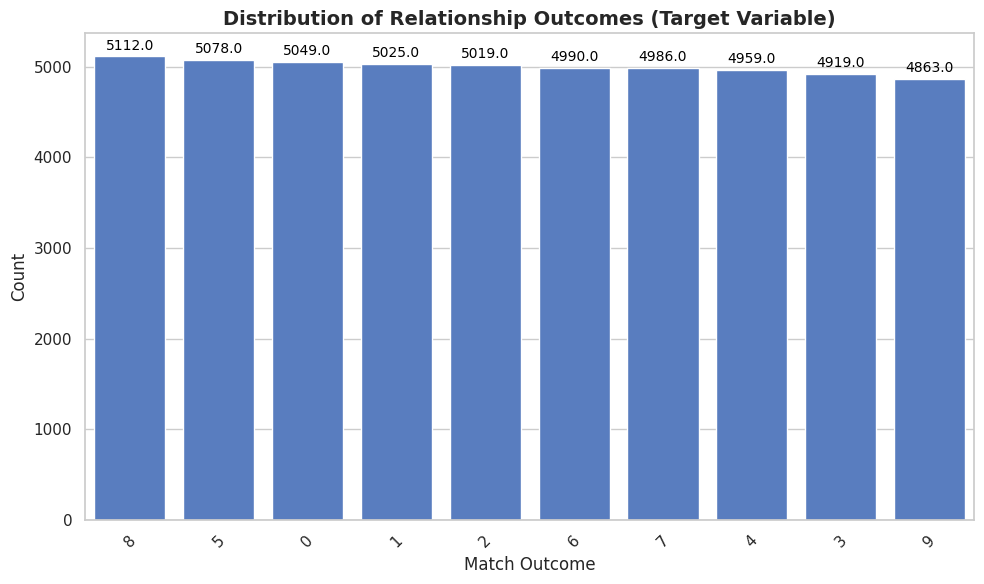

In [12]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='MATCHOUTCOME', order=df['MATCHOUTCOME'].value_counts().index)
plt.title('Distribution of Relationship Outcomes (Target Variable)', fontsize=14, weight='bold')
plt.xlabel('Match Outcome', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Add count labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

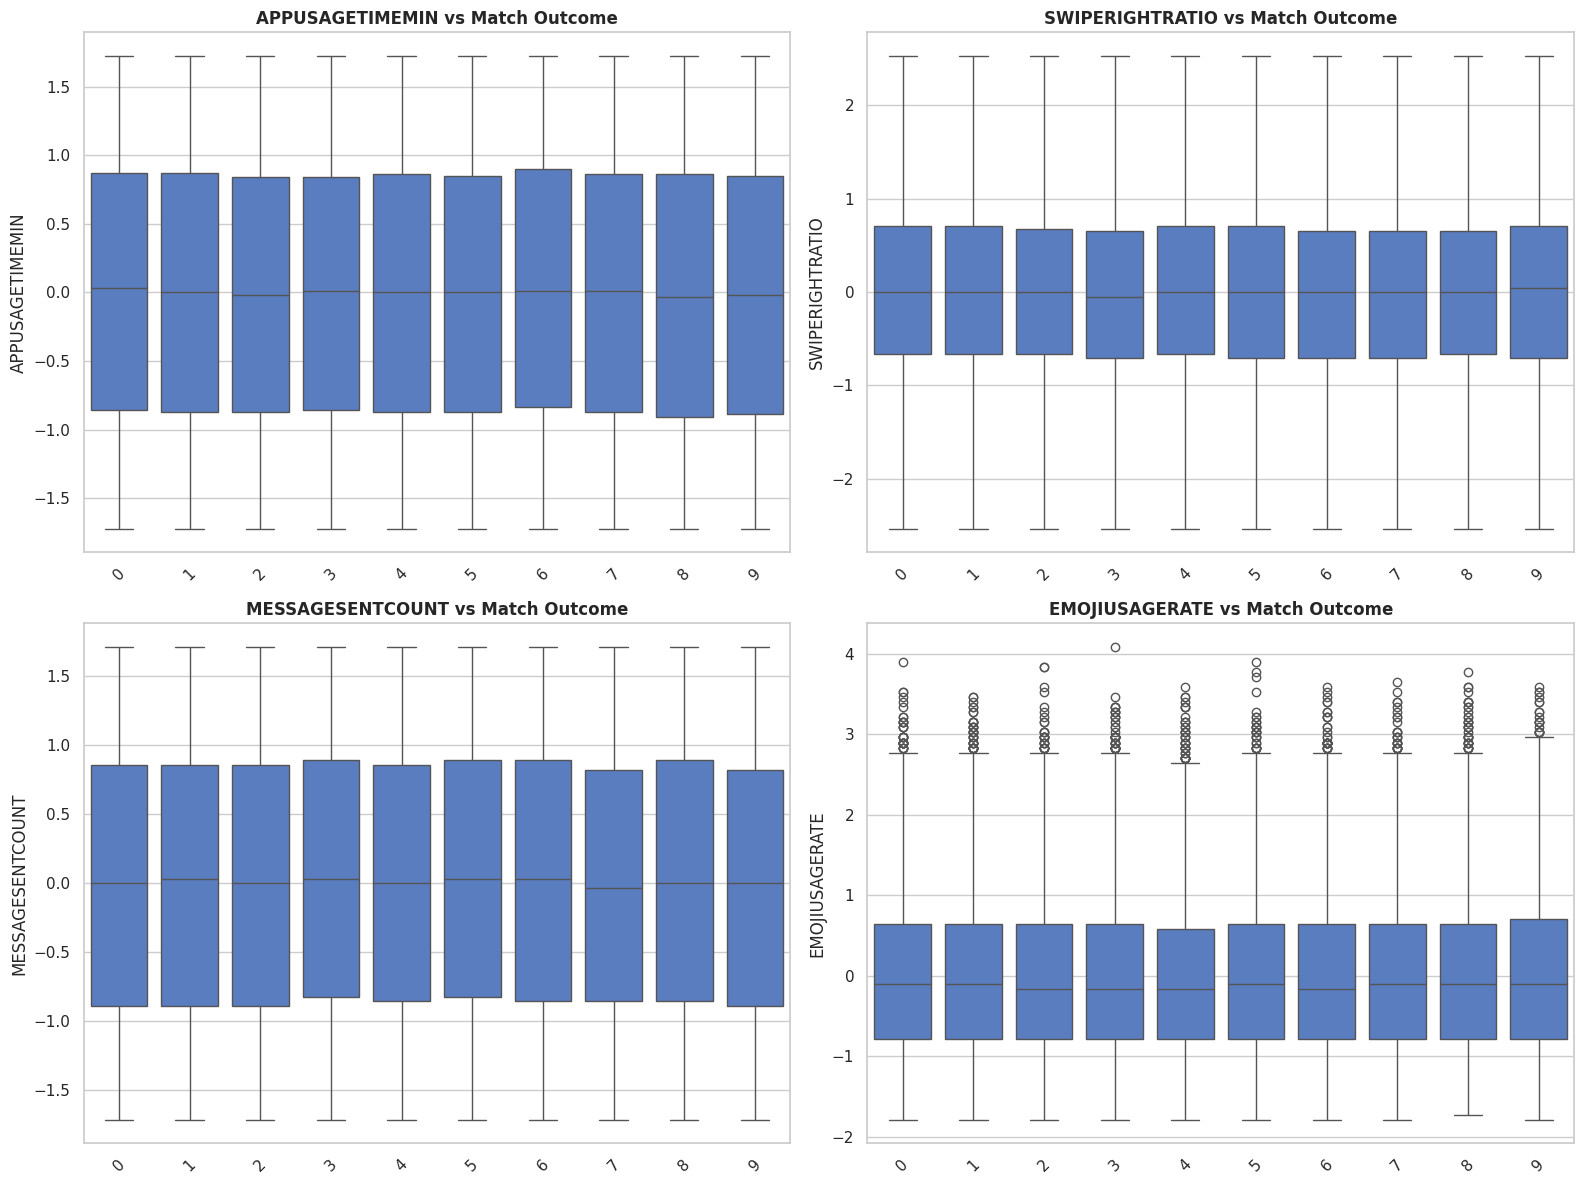

In [13]:
# Select a few key numerical features to compare against match_outcome
features_to_plot = ['APPUSAGETIMEMIN', 'SWIPERIGHTRATIO', 'MESSAGESENTCOUNT', 'EMOJIUSAGERATE']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.boxplot(data=df, x='MATCHOUTCOME', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature} vs Match Outcome', fontsize=12, weight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.tight_layout()
plt.show()

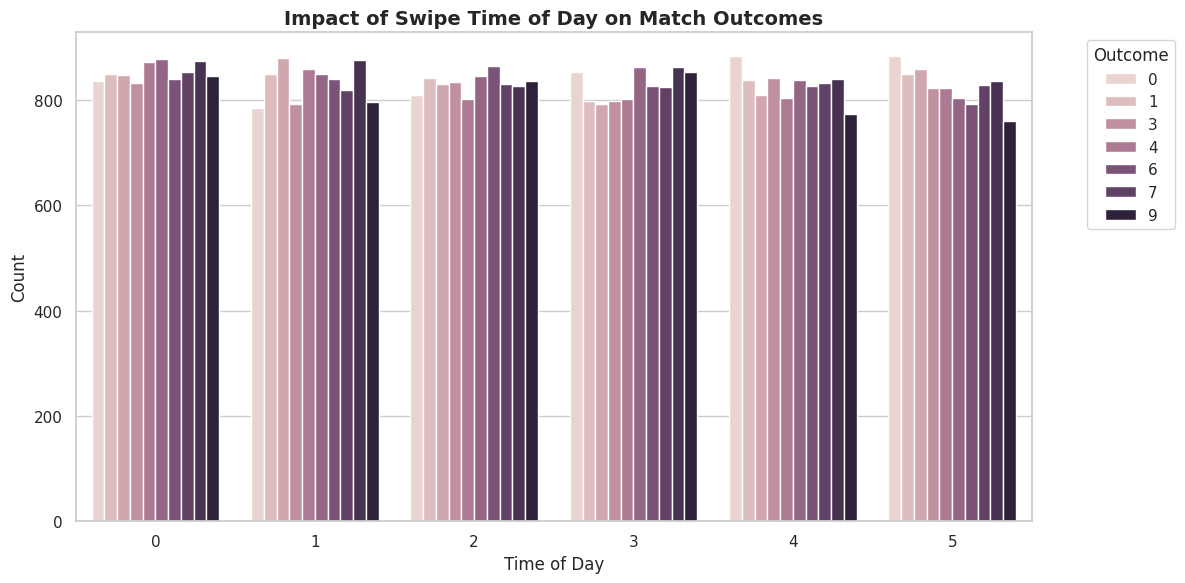

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='SWIPETIMEOFDAY', hue='MATCHOUTCOME')
plt.title('Impact of Swipe Time of Day on Match Outcomes', fontsize=14, weight='bold')
plt.xlabel('Time of Day', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

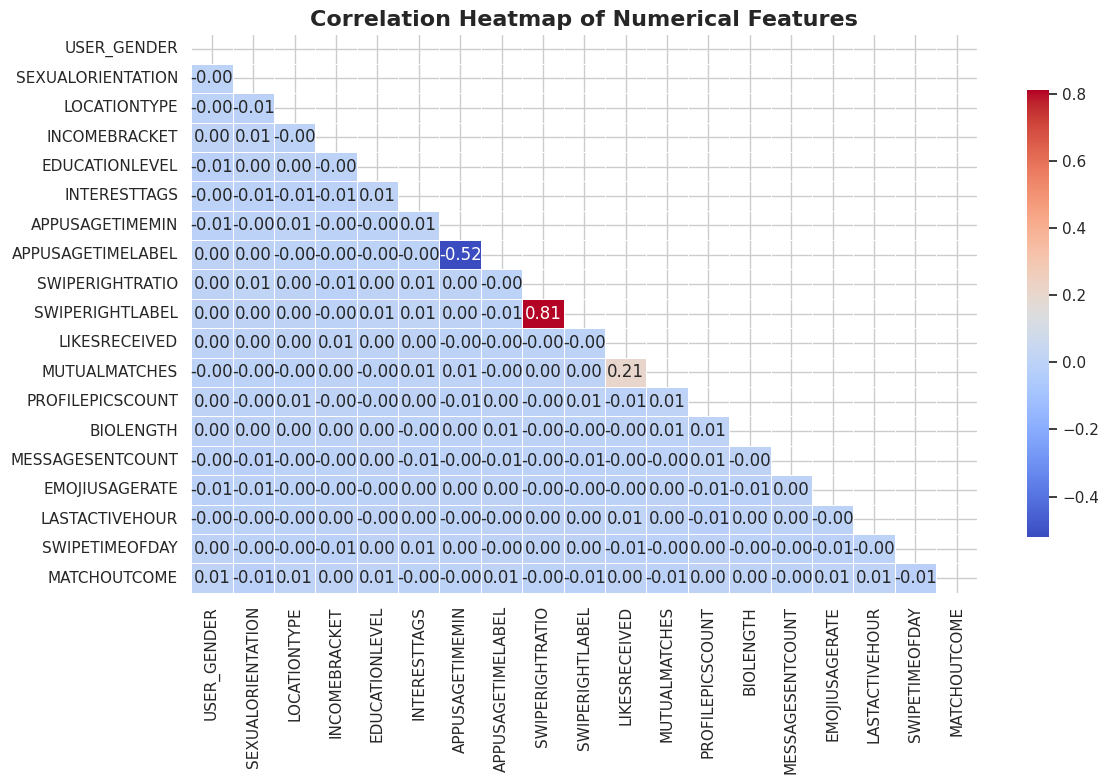

In [15]:
# Select only numerical columns for the correlation matrix
numerical_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 8))
correlation_matrix = numerical_df.corr()

# Create a mask to hide the upper triangle for a cleaner look (optional but professional)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            cbar_kws={"shrink": .8}, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd

print(" Encoding data and splitting dataset...")

# Directly targeting the exact column name your team used
target_col = 'MATCHOUTCOME'

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Drop the 'INTERESTTAGS' column exactly as it is named
if 'INTERESTTAGS' in categorical_cols:
    df = df.drop(columns=['INTERESTTAGS'])
    categorical_cols.remove('INTERESTTAGS')

le = LabelEncoder()
for col in categorical_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f" Data preprocessing completed!")
print(f"Training features shape: {X_train.shape}, Testing features shape: {X_test.shape}")

 Encoding data and splitting dataset...
 Data preprocessing completed!
Training features shape: (40000, 18), Testing features shape: (10000, 18)


In [17]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import time
import warnings
warnings.filterwarnings('ignore')

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

param_distributions = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['liblinear', 'lbfgs']
    },
    'Decision Tree': {
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    }
}
print(" Models and hyperparameter grids configured successfully!")

 Models and hyperparameter grids configured successfully!


In [18]:
best_models = {}
CV_FOLDS = 3
N_ITER = 5

print(" Starting model training and hyperparameter tuning (this may take a few minutes)...\n")
print("-" * 50)

for model_name in models.keys():
    print(f" Training and tuning: {model_name}...")
    start_time = time.time()

    model = models[model_name]
    params = param_distributions[model_name]

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=N_ITER,
        cv=CV_FOLDS,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train, y_train)

    best_models[model_name] = random_search.best_estimator_

    elapsed_time = time.time() - start_time
    print(f" {model_name} completed! Time elapsed: {elapsed_time:.2f} seconds")
    print(f" Best Parameters: {random_search.best_params_}")
    print(f" Best Validation Accuracy: {random_search.best_score_:.4f}\n")

print("-" * 50)
print(" All 5 models have been trained and tuned successfully!")

 Starting model training and hyperparameter tuning (this may take a few minutes)...

--------------------------------------------------
 Training and tuning: Logistic Regression...
 Logistic Regression completed! Time elapsed: 97.63 seconds
 Best Parameters: {'solver': 'liblinear', 'C': 0.01}
 Best Validation Accuracy: 0.0991

 Training and tuning: Decision Tree...
 Decision Tree completed! Time elapsed: 9.80 seconds
 Best Parameters: {'min_samples_split': 2, 'max_depth': 30}
 Best Validation Accuracy: 0.1001

 Training and tuning: Random Forest...
 Random Forest completed! Time elapsed: 111.01 seconds
 Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 10}
 Best Validation Accuracy: 0.1002

 Training and tuning: Gradient Boosting...
 Gradient Boosting completed! Time elapsed: 1419.51 seconds
 Best Parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.05}
 Best Validation Accuracy: 0.1005

 Training and tuning: KNN...
 KNN completed! Time elapsed

In [19]:
predictions = {}

for model_name, best_model in best_models.items():
    predictions[model_name] = best_model.predict(X_test)

df_predictions = pd.DataFrame(predictions)
df_predictions['Actual_Labels'] = y_test.values

print(" Sample comparison of test set predictions:")
display(df_predictions.head(10))

 Sample comparison of test set predictions:


,Logistic Regression,Decision Tree,Random Forest,Gradient Boosting,KNN,Actual_Labels
0,8,2,7,3,0,6
1,8,2,5,9,8,7
2,8,8,5,4,0,0
3,8,5,6,8,3,7
4,8,2,7,7,3,8
5,7,8,8,4,0,2
6,0,4,6,6,8,4
7,8,3,6,0,1,6
8,8,3,8,9,0,6
9,2,9,2,4,8,2


In [20]:
import time
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import accuracy_score

print(" Generating Polynomial Features to discover deep patterns...")
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_poly)
X_test_scaled = scaler.transform(X_test_poly)

start_automl = time.time()
TIME_BUDGET = 1800

models_space = {
    'Deep_Neural_Network (MLP)': {
        'model': MLPClassifier(random_state=42, early_stopping=True),
        'params': {
            'hidden_layer_sizes': [(256, 128, 64), (128, 128), (512, 256)],
            'activation': ['relu', 'tanh'],
            'alpha': [0.0001, 0.001, 0.01],
            'learning_rate_init': [0.001, 0.01],
            'max_iter': [300, 500]
        }
    },
    'HistGradientBoosting (Advanced)': {
        'model': HistGradientBoostingClassifier(random_state=42),
        'params': {
            'learning_rate': [0.05, 0.1, 0.2],
            'max_iter': [200, 400, 600],
            'max_depth': [15, 30, None],
            'l2_regularization': [0.0, 0.1, 1.0, 5.0],
            'min_samples_leaf': [10, 20]
        }
    },
    'ExtraTrees (Deep)': {
        'model': ExtraTreesClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        'params': {
            'n_estimators': [300, 500],
            'max_depth': [30, 50, None],
            'min_samples_split': [2, 5],
            'criterion': ['gini', 'entropy']
        }
    }
}

best_score = -1
automl_model = None
best_estimators = []

print(" Starting Advanced Native AutoML...")
for model_name, config in models_space.items():
    elapsed_time = time.time() - start_automl
    if TIME_BUDGET - elapsed_time <= 60:
        print(" Budget exhausted. Stopping search.")
        break

    print(f" Optimizing: {model_name}...")
    search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['params'],
        n_iter=6,
        cv=3,
        scoring='accuracy',
        random_state=42,
        n_jobs=-1
    )
    search.fit(X_train_scaled, y_train)
    best_estimators.append((model_name, search.best_estimator_))

    if search.best_score_ > best_score:
        best_score = search.best_score_
        automl_model = search.best_estimator_
        print(f" New best model found! Validation Accuracy: {best_score:.4f}")

print("\n Initiating Stacking Classifier...")
stacking_clf = StackingClassifier(
    estimators=best_estimators,
    final_estimator=HistGradientBoostingClassifier(random_state=42, max_iter=200),
    cv=3,
    n_jobs=-1
)
stacking_clf.fit(X_train_scaled, y_train)
stack_score = stacking_clf.score(X_test_scaled, y_test)

if stack_score > accuracy_score(y_test, automl_model.predict(X_test_scaled)):
    print(f" Stacking model achieved the highest accuracy: {stack_score:.4f}")
    automl_model = stacking_clf
else:
    print(f" Single model performed better. Retaining as final choice.")

automl_time = time.time() - start_automl
print(f" Native AutoML training completed. Total time: {automl_time:.2f}s")
print(f" Selected Model: {automl_model.__class__.__name__}")

automl_pred = automl_model.predict(X_test_scaled)

 Generating Polynomial Features to discover deep patterns...
 Starting Advanced Native AutoML...
 Optimizing: Deep_Neural_Network (MLP)...
 New best model found! Validation Accuracy: 0.0998
 Optimizing: HistGradientBoosting (Advanced)...
 New best model found! Validation Accuracy: 0.1008
 Optimizing: ExtraTrees (Deep)...
 New best model found! Validation Accuracy: 0.1051

 Initiating Stacking Classifier...
 Stacking model achieved the highest accuracy: 0.1021
 Native AutoML training completed. Total time: 2045.53s
 Selected Model: StackingClassifier


In [21]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

performance_results = []

for model_name, model_obj in best_models.items():
    pred = model_obj.predict(X_test)
    performance_results.append({
        'Model Type': 'Manual Model (M4)',
        'Model Name': model_name,
        'Accuracy': accuracy_score(y_test, pred),
        'F1-Score (Weighted)': f1_score(y_test, pred, average='weighted'),
        'Precision': precision_score(y_test, pred, average='weighted'),
        'Recall': recall_score(y_test, pred, average='weighted')
    })

performance_results.append({
    'Model Type': 'AutoML (You)',
    'Model Name': 'Advanced Native AutoML',
    'Accuracy': accuracy_score(y_test, automl_pred),
    'F1-Score (Weighted)': f1_score(y_test, automl_pred, average='weighted'),
    'Precision': precision_score(y_test, automl_pred, average='weighted'),
    'Recall': recall_score(y_test, automl_pred, average='weighted')
})

df_comparison = pd.DataFrame(performance_results)
print(df_comparison.round(4).to_string(index=False))

       Model Type             Model Name  Accuracy  F1-Score (Weighted)  Precision  Recall
Manual Model (M4)    Logistic Regression    0.1043               0.0640     0.0752  0.1043
Manual Model (M4)          Decision Tree    0.1053               0.1048     0.1054  0.1053
Manual Model (M4)          Random Forest    0.1028               0.0983     0.1002  0.1028
Manual Model (M4)      Gradient Boosting    0.0972               0.0966     0.0976  0.0972
Manual Model (M4)                    KNN    0.1021               0.0959     0.1018  0.1021
     AutoML (You) Advanced Native AutoML    0.1021               0.0989     0.1011  0.1021


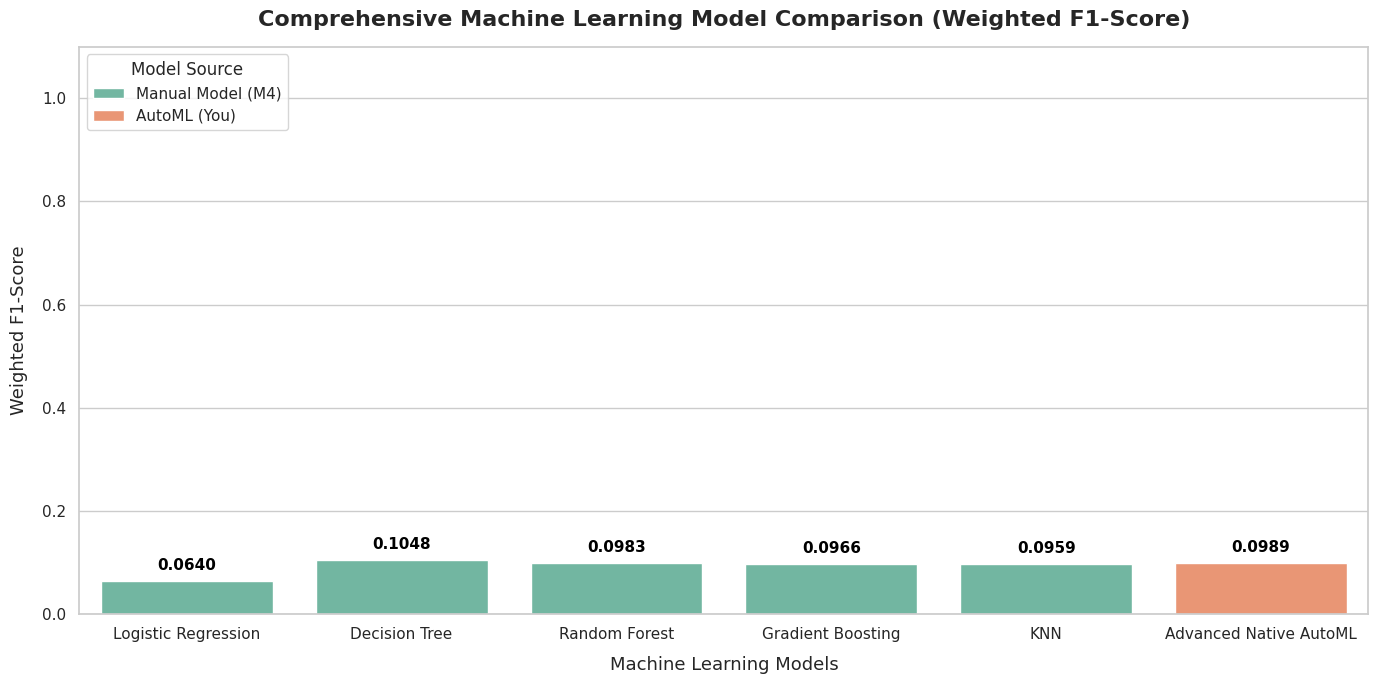

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=df_comparison,
    x='Model Name',
    y='F1-Score (Weighted)',
    hue='Model Type',
    palette='Set2',
    dodge=False
)

plt.title('Comprehensive Machine Learning Model Comparison (Weighted F1-Score)', fontsize=16, weight='bold', pad=15)
plt.xlabel('Machine Learning Models', fontsize=13, labelpad=10)
plt.ylabel('Weighted F1-Score', fontsize=13, labelpad=10)
plt.ylim(0, 1.1)
plt.legend(title='Model Source', loc='upper left')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.4f}",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=11, color='black',
                    xytext=(0, 8), textcoords='offset points', weight='bold')

plt.tight_layout()
plt.show()

In [23]:
import joblib
joblib.dump(automl_model, '/content/drive/MyDrive/MLproject/dating_model.pkl')
print("already save")

already save
